In [10]:
import warnings
warnings.filterwarnings("ignore")

#!pip install pyyaml

In [2]:
!pip install scikit-learn
!pip install matplotlib 
!pip install opencv-python
!pip install pandas
!pip install seaborn
!pip install tensorflow 
!pip install keras
!pip install pillow

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import (
    Input, ZeroPadding2D, Dense, Dropout, Activation, 
    Conv2D, AveragePooling2D, GlobalAveragePooling2D, MaxPooling2D,
    BatchNormalization, concatenate
)
from tensorflow.keras.models import Model
from sklearn.metrics import log_loss
import numpy as np
import os
import random
import cv2
import math
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [6]:

def conv_block(x, stage, branch, nb_filter, dropout_rate=None):
    '''Apply BatchNorm, Relu, bottleneck 1x1 Conv2D, 3x3 Conv2D, and option dropout '''

    # 1x1 Convolution (Bottleneck layer)
    inter_channel = nb_filter * 4  
    x = BatchNormalization(axis=concat_axis)(x)
    x = Scale(axis=concat_axis)(x)
    x = Activation('relu')(x)
    x = Convolution2D(inter_channel, 1, 1, bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    # 3x3 Convolution
    x = BatchNormalization(axis=concat_axis)(x)
    x = Scale(axis=concat_axis)(x)
    x = Activation('relu')(x)
    x = ZeroPadding2D((1, 1))(x)
    x = Convolution2D(nb_filter, 3, 3, bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    return x


def transition_block(x, stage, nb_filter, dropout_rate=None):
    ''' Apply BatchNorm, 1x1 Convolution, averagePooling, optional compression, dropout  '''


    x = BatchNormalization(axis=concat_axis)(x)
    x = Scale(axis=concat_axis)(x)
    x = Activation('relu')(x)
    x = Convolution2D(int(nb_filter), 1, 1, bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    x = AveragePooling2D((2, 2), strides=(2, 2))(x)

    return x


def dense_block(x, stage, nb_layers, nb_filter, growth_rate, dropout_rate=None, grow_nb_filters=True):
    ''' Build a dense_block where the output of each conv_block is fed to subsequent ones
        # Arguments
            x: input tensor
            stage: index for dense block
            nb_layers: the number of layers of conv_block to append to the model.
            nb_filter: number of filters
            growth_rate: growth rate
            grow_nb_filters: flag to decide to allow number of filters to grow
    '''

    concat_feat = x

    for i in range(nb_layers):
        branch = i+1
        x = conv_block(concat_feat, stage, branch, growth_rate, dropout_rate)
        concat_feat = merge([concat_feat, x], mode='concat', concat_axis=concat_axis)

        if grow_nb_filters:
            nb_filter += growth_rate

    return concat_feat, nb_filter


In [12]:
from keras.models import Model
from keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, Dense, Dropout,
    ZeroPadding2D, AveragePooling2D, GlobalAveragePooling2D, MaxPooling2D,
    Concatenate
)
from keras.optimizers import SGD
from keras import backend as K

# Custom Scale layer (to match original implementation)
from keras.layers import Layer
import tensorflow as tf

class Scale(Layer):
    """Learns a set of weights and biases used for scaling the input data."""
    def __init__(self, axis=-1, **kwargs):
        super(Scale, self).__init__(**kwargs)
        self.axis = axis

    def build(self, input_shape):
        shape = (int(input_shape[self.axis]),)
        self.gamma = self.add_weight(name='gamma',
                                     shape=shape,
                                     initializer='ones',
                                     trainable=True)
        self.beta = self.add_weight(name='beta',
                                    shape=shape,
                                    initializer='zeros',
                                    trainable=True)
        super(Scale, self).build(input_shape)

    def call(self, inputs, **kwargs):
        return self.gamma * inputs + self.beta

    def compute_output_shape(self, input_shape):
        return input_shape


def conv_block(x, stage, branch, nb_filter, dropout_rate=None):
    """Apply BN, ReLU, bottleneck (1x1 Conv2D), then 3x3 Conv2D."""
    inter_channel = nb_filter * 4

    x = BatchNormalization(axis=-1)(x)
    x = Scale(axis=-1)(x)
    x = Activation('relu')(x)
    x = Conv2D(inter_channel, (1, 1), use_bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    x = BatchNormalization(axis=-1)(x)
    x = Scale(axis=-1)(x)
    x = Activation('relu')(x)
    x = ZeroPadding2D((1, 1))(x)
    x = Conv2D(nb_filter, (3, 3), use_bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    return x


def transition_block(x, stage, nb_filter, dropout_rate=None):
    """Apply BN, ReLU, 1x1 Conv2D, optional dropout, then average pooling."""
    x = BatchNormalization(axis=-1)(x)
    x = Scale(axis=-1)(x)
    x = Activation('relu')(x)
    x = Conv2D(int(nb_filter), (1, 1), use_bias=False)(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    x = AveragePooling2D((2, 2), strides=(2, 2))(x)
    return x


def dense_block(x, stage, nb_layers, nb_filter, growth_rate, dropout_rate=None, grow_nb_filters=True):
    """Build a dense block where each layer receives inputs from all previous layers."""
    concat_feat = x
    for i in range(nb_layers):
        branch = i + 1
        cb = conv_block(concat_feat, stage, branch, growth_rate, dropout_rate)
        concat_feat = Concatenate(axis=-1)([concat_feat, cb])
        if grow_nb_filters:
            nb_filter += growth_rate
    return concat_feat, nb_filter


def densenet121_model(img_rows, img_cols, color_type=3, nb_dense_block=4,
                      growth_rate=32, nb_filter=64, reduction=0.5, dropout_rate=0.0,
                      weight_decay=1e-4, num_classes=4):
    """
    DenseNet-121 implementation compatible with TensorFlow 2.x
    """

    img_input = Input(shape=(img_rows, img_cols, color_type), name='data')

    nb_layers = [6, 12, 24, 16]  # DenseNet-121 configuration

    # Initial convolution
    x = Conv2D(nb_filter, (7, 7), strides=(2, 2), padding='same',
               name='conv1', use_bias=False)(img_input)
    x = BatchNormalization(axis=-1)(x)
    x = Scale(axis=-1)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Add dense blocks
    for block_idx in range(nb_dense_block - 1):
        stage = block_idx + 2
        x, nb_filter = dense_block(x, stage, nb_layers[block_idx],
                                   nb_filter, growth_rate, dropout_rate)
        x = transition_block(x, stage, nb_filter, dropout_rate)
        nb_filter = int(nb_filter * reduction)

    # Final dense block
    final_stage = stage + 1
    x, nb_filter = dense_block(x, final_stage, nb_layers[-1],
                               nb_filter, growth_rate, dropout_rate)

    x = BatchNormalization(axis=-1)(x)
    x = Scale(axis=-1)(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(num_classes, activation='softmax')(x)

    model = Model(img_input, x)

    # Compile model
    sgd = SGD(learning_rate=1e-3, decay=1e-6, momentum=0.9, nesterov=True)
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [14]:
import os
import random
import cv2
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from keras.utils import img_to_array

# Paths
train_dir = r"C:\Users\abhir\OneDrive\Documents\Projects\DIP - Retinal Disease classification\OCT\OCT\train"
test_dir = r"C:\Users\abhir\OneDrive\Documents\Projects\DIP - Retinal Disease classification\OCT\OCT\test"

def load_data(data_dir, max_images_per_class=1500):
    data = []
    labels = []
    random.seed(42)
    
    class_folders = sorted(os.listdir(data_dir))
    for class_name in class_folders:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        
        image_files = os.listdir(class_path)
        random.shuffle(image_files)
        image_files = image_files[:max_images_per_class]  
        
        print(f"Loading {len(image_files)} images from class '{class_name}'...")
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.resize(image, (224, 224))
            image = img_to_array(image)
            data.append(image)
            labels.append(class_name)

    data = np.array(data, dtype="float32") / 255.0
    labels = np.array(labels)
    
    mlb = LabelBinarizer()
    labels = mlb.fit_transform(labels)
    
    print(f"✅ Loaded {len(data)} images from {len(class_folders)} classes.")
    return data, labels

# Load limited data
x_train, y_train = load_data(train_dir, max_images_per_class=1500)
x_test, y_test = load_data(test_dir, max_images_per_class=300)  

print(f"Train data shape: {x_train.shape}, Train labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}, Test labels shape: {y_test.shape}")

Loading 1500 images from class 'CNV'...
Loading 1500 images from class 'DME'...
Loading 1500 images from class 'DRUSEN'...
Loading 1500 images from class 'NORMAL'...
✅ Loaded 6000 images from 4 classes.
Loading 250 images from class 'CNV'...
Loading 250 images from class 'DME'...
Loading 250 images from class 'DRUSEN'...
Loading 250 images from class 'NORMAL'...
✅ Loaded 1000 images from 4 classes.
Train data shape: (6000, 224, 224, 3), Train labels shape: (6000, 4)
Test data shape: (1000, 224, 224, 3), Test labels shape: (1000, 4)


In [16]:
# Check CUDA and GPU availability with TensorFlow
!python --version
print()
!nvcc --version
print()
!nvidia-smi

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Is GPU available?", tf.config.list_physical_devices('GPU'))

Python 3.10.18

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Aug_20_13:58:20_Pacific_Daylight_Time_2025
Cuda compilation tools, release 13.0, V13.0.88
Build cuda_13.0.r13.0/compiler.36424714_0

Sun Oct  5 23:40:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.26                 Driver Version: 566.26         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0  On |             

In [17]:
!conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0


^C


In [7]:
# Check CUDA and GPU availability with PyTorch
import torch
print("PyTorch version:", torch.__version__)
print("Is CUDA available?", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

ModuleNotFoundError: No module named 'torch'

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4477 - loss: 1.2060
Epoch 1: val_accuracy improved from None to 0.25000, saving model to bestmodel.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 997s 4s/step - accuracy: 0.5272 - loss: 1.0674 - val_accuracy: 0.2500 - val_loss: 2.3221
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6354 - loss: 0.8633
Epoch 2: val_accuracy improved from 0.25000 to 0.26700, saving model to bestmodel.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 876s 4s/step - accuracy: 0.6503 - loss: 0.8335 - val_accuracy: 0.2670 - val_loss: 1.5580
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7430 - loss: 0.6754
Epoch 3: val_accuracy improved from 0.26700 to 0.30300, saving model to bestmodel.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 863s 3s/step - accuracy: 0.7437 - loss: 0.6580 - val_accuracy: 0.3030 - val_loss: 1.4785
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7873 - loss: 0.5707
Epoch 4: val_accuracy improved from 0.30300 t

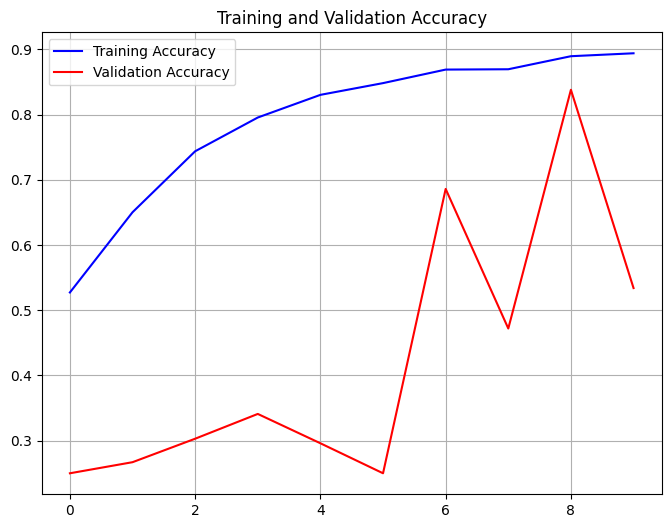

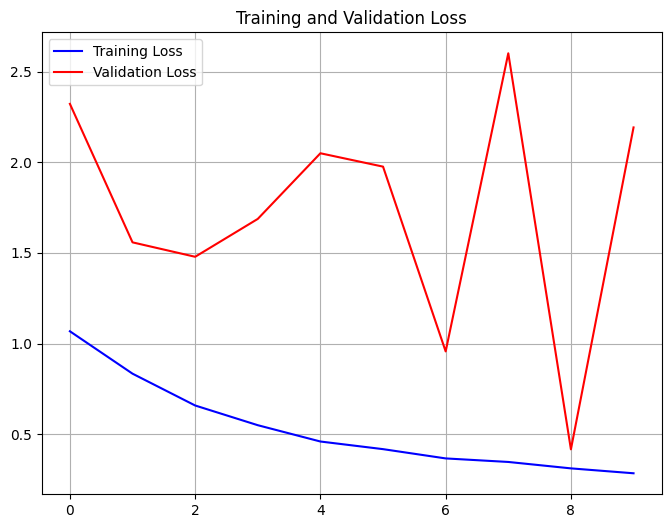

In [7]:
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

if __name__ == '__main__':

    img_rows, img_cols = 224, 224  # input size
    channel = 3
    num_classes = 4
    batch_size = 16
    epochs = 10  # renamed from nb_epoch

    # Use already-loaded data
    X_train, Y_train = x_train, y_train
    X_valid, Y_valid = x_test, y_test

    # Initialize your DenseNet model
    model = densenet121_model(
        img_rows=img_rows,
        img_cols=img_cols,
        color_type=channel,
        num_classes=num_classes
    )

    # Model checkpoint to save best weights
    filepath = "bestmodel.keras"
    checkpoint = ModelCheckpoint(
        filepath,
        monitor='val_accuracy',  # updated metric name
        verbose=1,
        save_best_only=True,
        mode='max'
    )
    callbacks_list = [checkpoint]

    # Start Fine-tuning
    history = model.fit(
        X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        verbose=1,
        validation_data=(X_valid, Y_valid),
        callbacks=callbacks_list
    )

    # Make predictions
    predictions_valid = model.predict(X_valid, batch_size=batch_size, verbose=1)

    # Cross-entropy loss score
    score = log_loss(Y_valid, predictions_valid)
    print("Validation log loss:", score)

    # ---------------------------
    # Evaluate Accuracy and Loss
    # ---------------------------

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    # Plot accuracy
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, acc, 'b', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot loss
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, loss, 'b', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [9]:
from keras.models import load_model

model = load_model("final.keras")


ValueError: File not found: filepath=final.keras. Please ensure the file is an accessible `.keras` zip file.

In [8]:
# Save final model after training
model.save("final_model.keras")

# Optional: Load and evaluate best model
from keras.models import load_model
best_model = load_model("bestmodel.keras")
best_loss, best_acc = best_model.evaluate(X_valid, Y_valid, verbose=0)
print(f"Best model accuracy: {best_acc:.4f}")


TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'SGD', 'config': {'name': 'SGD', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'momentum': 0.9, 'nesterov': True}, 'registered_name': None}, 'loss': 'categorical_crossentropy', 'loss_weights': None, 'metrics': ['accuracy'], 'weighted_metrics': None, 'run_eagerly': Fal

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4601 - loss: 1.1661
Epoch 1: val_accuracy improved from None to 0.25100, saving model to bestmodel.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1535s 4s/step - accuracy: 0.5445 - loss: 1.0286 - val_accuracy: 0.2510 - val_loss: 1.8323
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6693 - loss: 0.8091
Epoch 2: val_accuracy improved from 0.25100 to 0.54100, saving model to bestmodel.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1590s 4s/step - accuracy: 0.6967 - loss: 0.7601 - val_accuracy: 0.5410 - val_loss: 1.0191
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7816 - loss: 0.5717
Epoch 3: val_accuracy did not improve from 0.54100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1457s 4s/step - accuracy: 0.7953 - loss: 0.5404 - val_accuracy: 0.3520 - val_loss: 1.7199
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8228 - loss: 0.4824
Epoch 4: val_accuracy did not improve from 0.54100
375/375 ━━━━━━━━━━━━━━━━━━━━

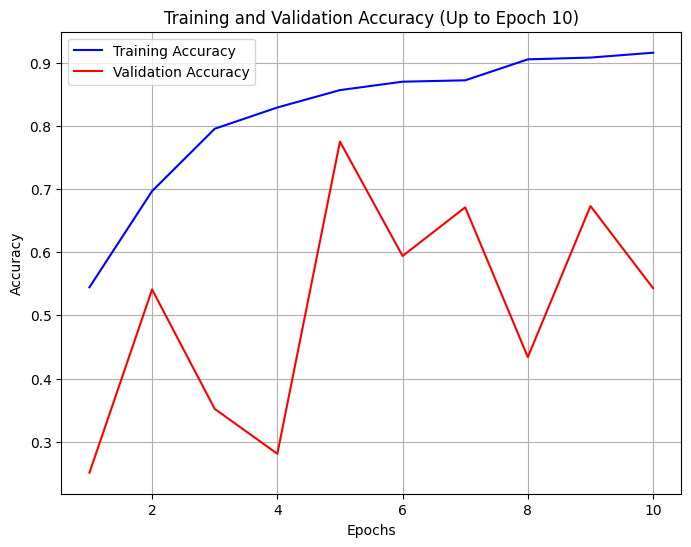

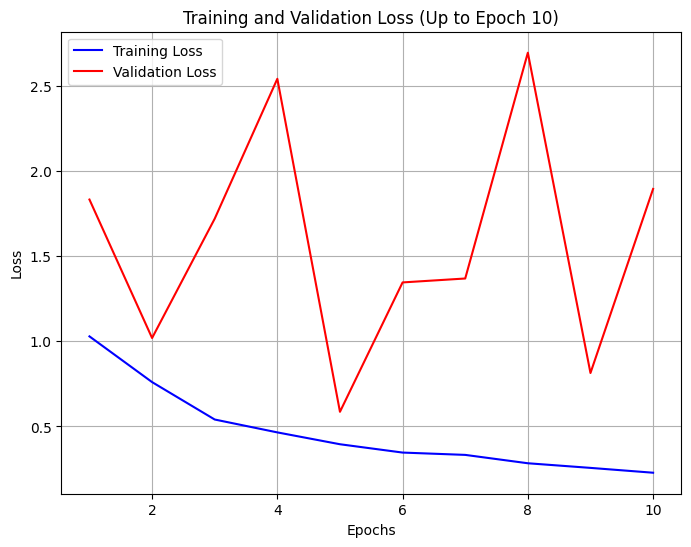

375/375 ━━━━━━━━━━━━━━━━━━━━ 1282s 3s/step - accuracy: 0.9157 - loss: 0.2279 - val_accuracy: 0.5430 - val_loss: 1.8946
Epoch 11/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9289 - loss: 0.1974
Epoch 11: val_accuracy did not improve from 0.77500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1274s 3s/step - accuracy: 0.9290 - loss: 0.2077 - val_accuracy: 0.4200 - val_loss: 3.7426
Epoch 12/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9355 - loss: 0.1877
Epoch 12: val_accuracy did not improve from 0.77500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1280s 3s/step - accuracy: 0.9305 - loss: 0.1974 - val_accuracy: 0.6760 - val_loss: 1.0239
Epoch 13/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9386 - loss: 0.1688
Epoch 13: val_accuracy did not improve from 0.77500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1281s 3s/step - accuracy: 0.9380 - loss: 0.1774 - val_accuracy: 0.6720 - val_loss: 1.3311
Epoch 14/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9421 - loss: 0.1813
Epoch 14: val_accuracy d

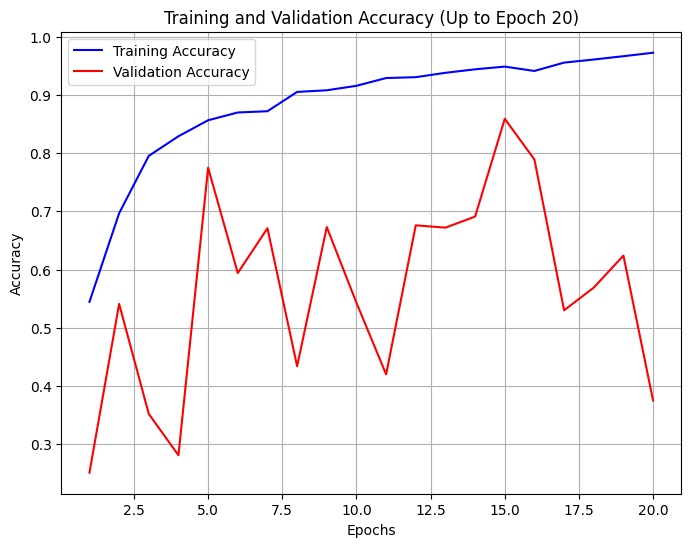

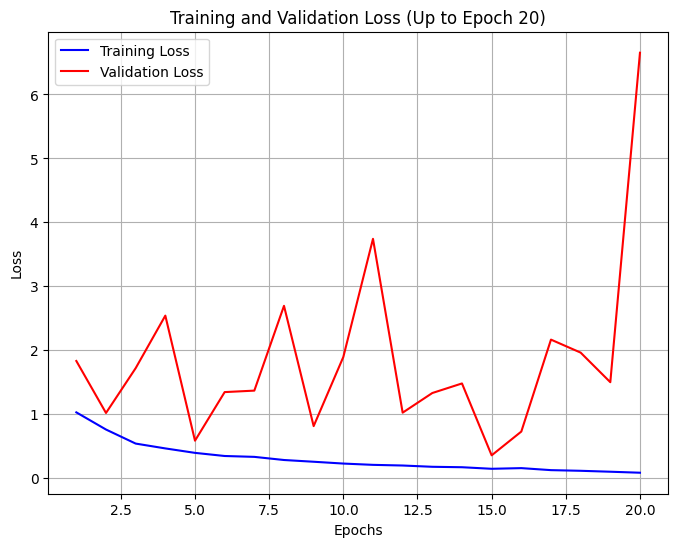

375/375 ━━━━━━━━━━━━━━━━━━━━ 1244s 3s/step - accuracy: 0.9725 - loss: 0.0846 - val_accuracy: 0.3750 - val_loss: 6.6531
Epoch 21/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9728 - loss: 0.0758
Epoch 21: val_accuracy did not improve from 0.85900
375/375 ━━━━━━━━━━━━━━━━━━━━ 1238s 3s/step - accuracy: 0.9745 - loss: 0.0740 - val_accuracy: 0.8560 - val_loss: 0.4483
Epoch 22/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9763 - loss: 0.0688
Epoch 22: val_accuracy improved from 0.85900 to 0.91300, saving model to bestmodel.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1241s 3s/step - accuracy: 0.9762 - loss: 0.0703 - val_accuracy: 0.9130 - val_loss: 0.2485
Epoch 23/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9755 - loss: 0.0707
Epoch 23: val_accuracy did not improve from 0.91300
375/375 ━━━━━━━━━━━━━━━━━━━━ 1234s 3s/step - accuracy: 0.9733 - loss: 0.0756 - val_accuracy: 0.6130 - val_loss: 1.7862
Epoch 24/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9748 - 

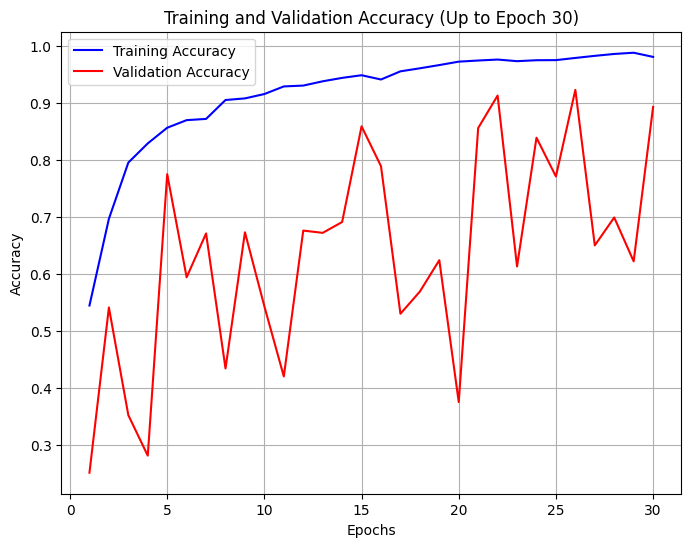

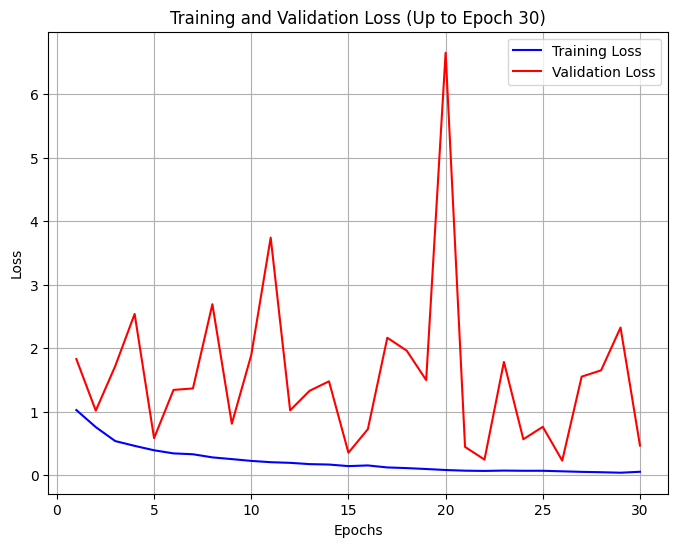

375/375 ━━━━━━━━━━━━━━━━━━━━ 1246s 3s/step - accuracy: 0.9808 - loss: 0.0570 - val_accuracy: 0.8930 - val_loss: 0.4694
Epoch 31/40
299/375 ━━━━━━━━━━━━━━━━━━━━ 4:16 3s/step - accuracy: 0.9868 - loss: 0.0370

KeyboardInterrupt: 

In [15]:
from keras.callbacks import ModelCheckpoint, Callback
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

# --- Custom callback to plot after every 10 epochs ---
class PlotProgress(Callback):
    def __init__(self, interval=10):
        super().__init__()
        self.interval = interval
        self.history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for key in self.history.keys():
            if key in logs:
                self.history[key].append(logs[key])

        # Plot every 'interval' epochs
        if (epoch + 1) % self.interval == 0:
            self.plot_progress(epoch + 1)

    def plot_progress(self, epoch):
        acc = self.history['accuracy']
        val_acc = self.history['val_accuracy']
        loss = self.history['loss']
        val_loss = self.history['val_loss']
        epochs_range = range(1, len(acc) + 1)

        # Accuracy Plot
        plt.figure(figsize=(8, 6))
        plt.plot(epochs_range, acc, 'b', label='Training Accuracy')
        plt.plot(epochs_range, val_acc, 'r', label='Validation Accuracy')
        plt.title(f'Training and Validation Accuracy (Up to Epoch {epoch})')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Loss Plot
        plt.figure(figsize=(8, 6))
        plt.plot(epochs_range, loss, 'b', label='Training Loss')
        plt.plot(epochs_range, val_loss, 'r', label='Validation Loss')
        plt.title(f'Training and Validation Loss (Up to Epoch {epoch})')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

# ---------------------------
# Main training script
# ---------------------------
if __name__ == '__main__':

    img_rows, img_cols = 224, 224
    channel = 3
    num_classes = 4
    batch_size = 16
    epochs = 40  # now 40 epochs

    # Use already-loaded data
    X_train, Y_train = x_train, y_train
    X_valid, Y_valid = x_test, y_test

    # Initialize your DenseNet model
    model = densenet121_model(
        img_rows=img_rows,
        img_cols=img_cols,
        color_type=channel,
        num_classes=num_classes
    )

    # Save best model
    filepath = "bestmodel.keras"
    checkpoint = ModelCheckpoint(
        filepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max'
    )

    # Add our plotting callback
    plot_callback = PlotProgress(interval=10)
    callbacks_list = [checkpoint, plot_callback]

    # Train
    history = model.fit(
        X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        verbose=1,
        validation_data=(X_valid, Y_valid),
        callbacks=callbacks_list
    )

    # Predictions and evaluation
    predictions_valid = model.predict(X_valid, batch_size=batch_size, verbose=1)
    score = log_loss(Y_valid, predictions_valid)
    print("Validation log loss:", score)


In [16]:
predictions_valid = model.predict(X_valid, batch_size=batch_size, verbose=1)
score = log_loss(Y_valid, predictions_valid)
print("Validation log loss:", score)

63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step 
Validation log loss: 2.667220732015642


In [17]:
from sklearn.metrics import accuracy_score
import numpy as np

predicted_classes = np.argmax(predictions_valid, axis=1)
true_classes = np.argmax(Y_valid, axis=1)
acc = accuracy_score(true_classes, predicted_classes)
print("Validation Accuracy:", acc)


Validation Accuracy: 0.549


63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 835ms/step
Validation Log Loss: 0.23241358885761615
Validation Accuracy: 0.923


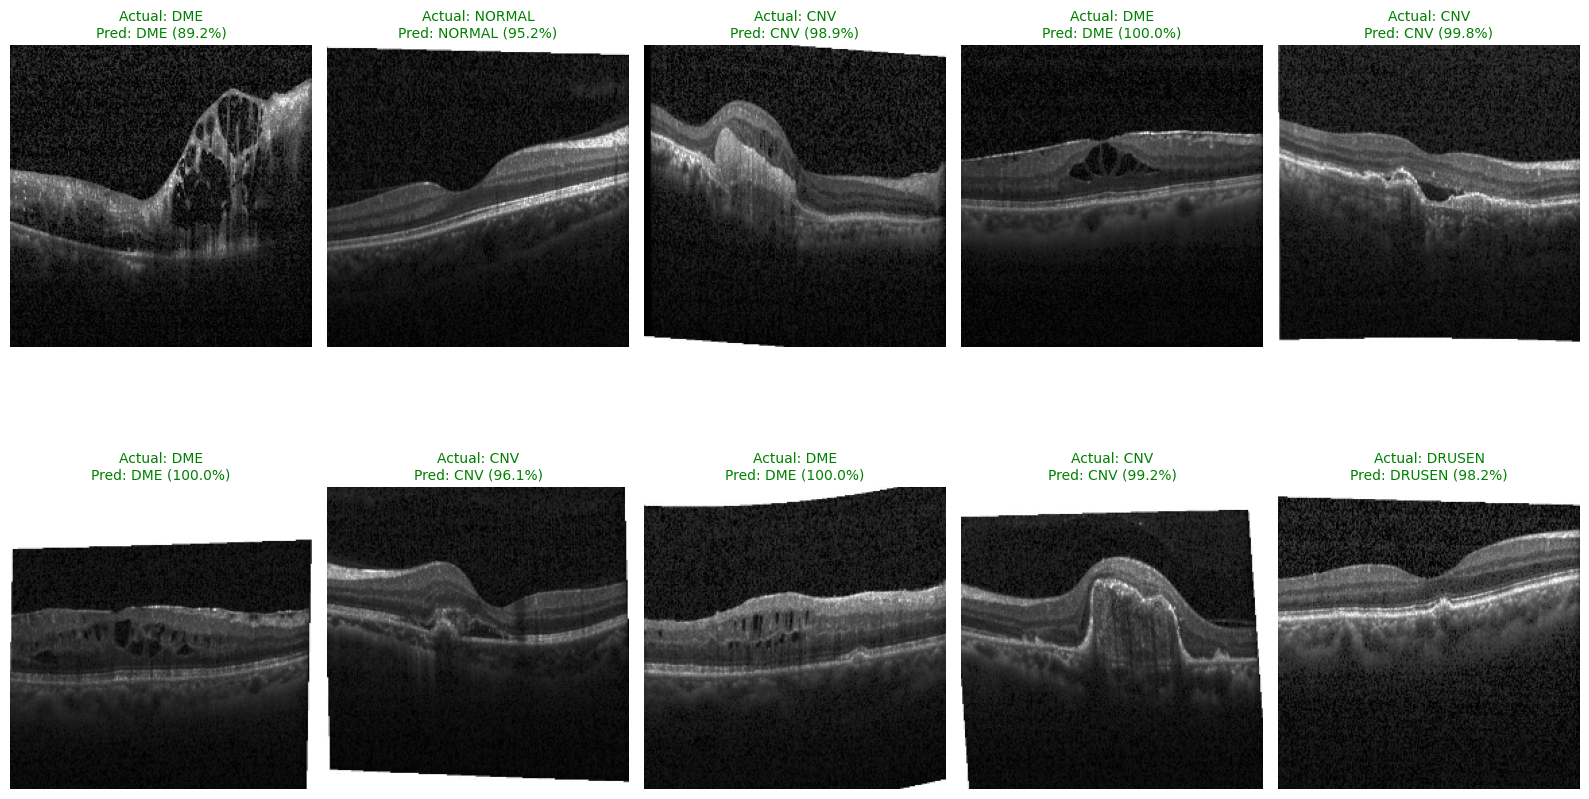

In [21]:
# ------------------------------------------------------------
# IMPORTS
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from keras.layers import Layer
from keras import backend as K
from sklearn.metrics import log_loss, accuracy_score

# ------------------------------------------------------------
# DEFINE CUSTOM SCALE LAYER (for DenseNet)
# ------------------------------------------------------------
class Scale(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(Scale, self).__init__(**kwargs)
        self.axis = axis

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma',
            shape=(input_shape[self.axis],),
            initializer='ones',
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(input_shape[self.axis],),
            initializer='zeros',
            trainable=True
        )
        super(Scale, self).build(input_shape)

    def call(self, inputs):
        broadcast_shape = [1] * len(inputs.shape)
        broadcast_shape[self.axis] = inputs.shape[self.axis]
        return self.gamma * inputs + self.beta

    def compute_output_shape(self, input_shape):
        return input_shape

# ------------------------------------------------------------
# LOAD THE TRAINED MODEL WITH CUSTOM LAYER
# ------------------------------------------------------------
model = load_model("bestmodel.keras", custom_objects={'Scale': Scale})

# ------------------------------------------------------------
# EVALUATE MODEL ON VALIDATION DATA
# ------------------------------------------------------------
predictions_valid = model.predict(X_valid, batch_size=batch_size, verbose=1)
score = log_loss(Y_valid, predictions_valid)
print("Validation Log Loss:", score)

y_true = np.argmax(Y_valid, axis=1)
y_pred = np.argmax(predictions_valid, axis=1)
acc = accuracy_score(y_true, y_pred)
print("Validation Accuracy:", acc)

# ------------------------------------------------------------
# VISUALIZE SOME PREDICTIONS
# ------------------------------------------------------------
# 🔹 Replace these with your actual class names
class_labels = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

num_samples = 10  # number of images to show
indices = np.random.choice(len(X_valid), num_samples, replace=False)

plt.figure(figsize=(16, 10))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)

    # Ensure valid image pixel range
    img = np.clip(X_valid[idx], 0, 1)

    plt.imshow(img)
    plt.axis("off")

    actual = class_labels[y_true[idx]]
    predicted = class_labels[y_pred[idx]]
    confidence = np.max(predictions_valid[idx]) * 100

    color = "green" if y_true[idx] == y_pred[idx] else "red"
    plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.1f}%)",
              color=color, fontsize=10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# (Optional) SAVE RESULTS TO FILE
# ------------------------------------------------------------
# plt.savefig("prediction_results.png", dpi=300)


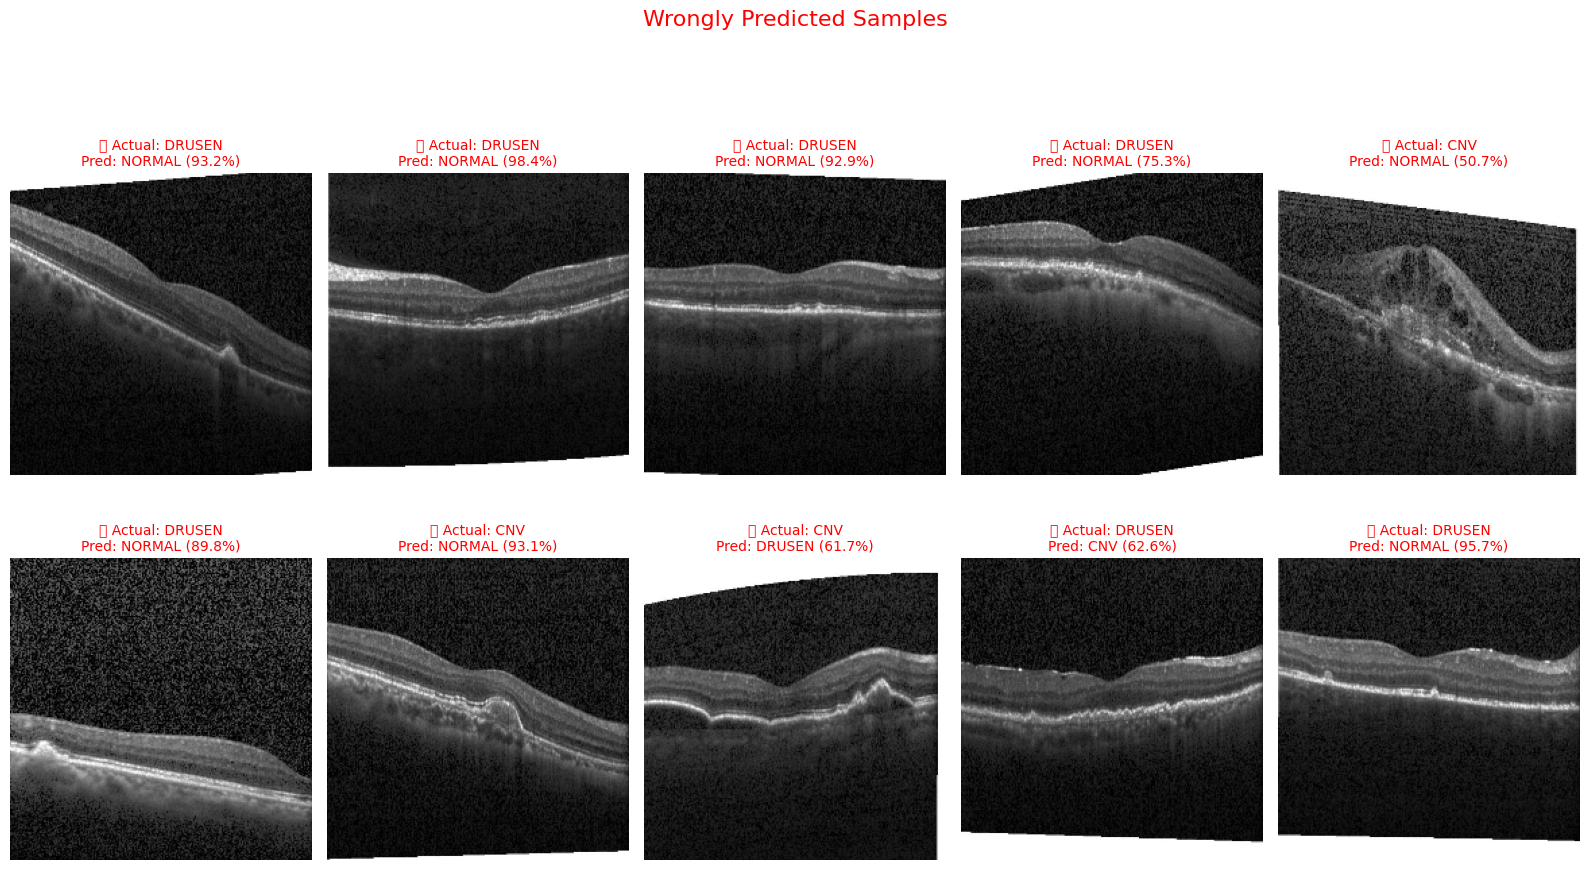

In [ ]:
class_labels = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
wrong_indices = np.where(y_true != y_pred)[0]
if len(wrong_indices) == 0:
    print("🎉 All images were classified correctly!")
else:
    num_samples = min(10, len(wrong_indices)) 
    chosen_indices = np.random.choice(wrong_indices, num_samples, replace=False)
    plt.figure(figsize=(16, 10))
    for i, idx in enumerate(chosen_indices):
        plt.subplot(2, 5, i + 1)
        img = np.clip(X_valid[idx], 0, 1)
        plt.imshow(img)
        plt.axis("off")
        actual = class_labels[y_true[idx]]
        predicted = class_labels[y_pred[idx]]
        confidence = np.max(predictions_valid[idx]) * 100
        plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.1f}%)",color="red", fontsize=10)
    plt.suptitle("Wrongly Predicted Samples", fontsize=16, color="red")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


------------------------------------------------
📊 Model Evaluation Metrics
------------------------------------------------
✅ Accuracy : 0.9230
🎯 Precision: 0.9301
📈 Recall   : 0.9230
💡 F1 Score : 0.9224
------------------------------------------------

Detailed Classification Report:

              precision    recall  f1-score   support

         CNV       0.92      0.93      0.93       250
         DME       0.97      0.98      0.98       250
      DRUSEN       0.99      0.80      0.88       250
      NORMAL       0.83      0.98      0.90       250

    accuracy                           0.92      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.93      0.92      0.92      1000



<Figure size 700x600 with 0 Axes>

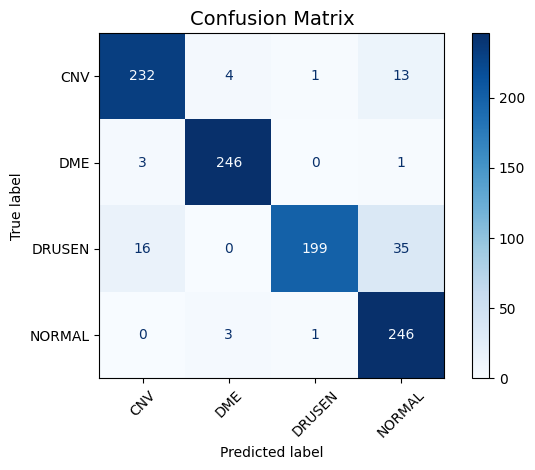

In [23]:
# ------------------------------------------------------------
# DETAILED METRICS: Accuracy, Precision, Recall, F1, Confusion Matrix
# ------------------------------------------------------------
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

# Class names (update if needed)
class_labels = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

# Compute metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("------------------------------------------------")
print("📊 Model Evaluation Metrics")
print("------------------------------------------------")
print(f"✅ Accuracy : {acc:.4f}")
print(f"🎯 Precision: {precision:.4f}")
print(f"📈 Recall   : {recall:.4f}")
print(f"💡 F1 Score : {f1:.4f}")
print("------------------------------------------------\n")

# Classification Report (per class)
print("Detailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
